In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install tensorflow

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, QuantileTransformer, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from datetime import datetime
from sklearn.model_selection import train_test_split
from matplotlib.backends.backend_pdf import PdfPages
import warnings

warnings.filterwarnings('ignore')

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Load Dataset

In [ ]:
d1 = pd.read_excel('/content/drive/MyDrive/Skripsi/Data Konsentrasi Parameter Kebonsari PM10 CO WIND TEMPERATUR HUMIDITY 2022.xlsx')
d1

,Tanggal,PM10,CO,Temp Of Air,Humidity,Wind Velocity,LOKASI
0,2022-01-01,52.21,0.63,27.53,0.46,1.16,Kebonsari
1,2022-01-02,32.31,0.63,26.98,0.46,0.59,Kebonsari
2,2022-01-03,38.93,0.63,27.85,0.46,0.73,Kebonsari
3,2022-01-04,57.83,0.63,26.81,0.46,0.48,Kebonsari
4,2022-01-05,69.72,0.63,27.51,0.46,0.63,Kebonsari
...,...,...,...,...,...,...,...
360,2022-12-27,30.79,0.18,27.2,0.46,1.25,Kebonsari
361,2022-12-28,37.68,0.08,28.65,0.46,1.35,Kebonsari
362,2022-12-29,33,0.15,27.2,0.46,1.38,Kebonsari
363,2022-12-30,41.93,0.3,26.36,0.46,1.24,Kebonsari


In [ ]:
d2 = pd.read_excel('/content/drive/MyDrive/Skripsi/Data Konsentrasi Parameter Kebonsari PM10 CO WIND TEMPERATUR HUMIDITY 2023.xlsx')
d2

,Tanggal,PM10,CO,Temp Of Air,Humidity,Wind Velocity,LOKASI
0,2023-01-01,28.34,0.06,27.31,0.46,1.6,Kebonsari
1,2023-01-02,29.71,0.1,28.09,0.46,1.85,Kebonsari
2,2023-01-03,28.96,0.05,28.51,0.46,1.92,Kebonsari
3,2023-01-04,36.43,0.19,28.91,0.46,1.79,Kebonsari
4,2023-01-05,32.88,0.17,28.92,0.46,1.53,Kebonsari
...,...,...,...,...,...,...,...
360,2023-12-27,26.92,2.17,32.07,66.02,0.9,Kebonsari
361,2023-12-28,75.37,2.83,30.13,60.5,0.62,Kebonsari
362,2023-12-29,82.26,2.8,30.57,41.32,0.81,Kebonsari
363,2023-12-30,53.27,2.5,29.7,79.1,0.97,Kebonsari


In [ ]:
d3 = pd.read_excel('/content/drive/MyDrive/Skripsi/Data Konsentrasi Parameter Kebonsari PM10 CO WIND TEMPERATUR HUMIDITY 2024.xlsx')
d3

,Tanggal,PM10,CO,Temp Of Air,Humidity,Wind Velocity,LOKASI
0,2024-01-01,56.46,2.57,29.94,73.64,0.6,Kebonsari
1,2024-01-02,37.01,2.62,30.75,72.66,0.64,Kebonsari
2,2024-01-03,57.67,3.22,28.2,91.51,0.6,Kebonsari
3,2024-01-04,72.96,2.76,29.56,70.66,0.85,Kebonsari
4,2024-01-05,79.34,2.78,28.73,83.04,0.7,Kebonsari
...,...,...,...,...,...,...,...
361,2024-12-27,52.65,3.78,30.33,67.34,0.67,Kebonsari
362,2024-12-28,40.06,3.81,29.23,38.38,0.85,Kebonsari
363,2024-12-29,30.48,3.66,28.34,18.31,1.04,Kebonsari
364,2024-12-30,40.66,4.14,28.69,16.68,0.89,Kebonsari


In [ ]:
df = pd.concat([d1, d2, d3], ignore_index=True)

df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df.set_index('Tanggal', inplace=True)



df.drop(columns=['LOKASI'], inplace=True)

df

,PM10,CO,Temp Of Air,Humidity,Wind Velocity
Tanggal,,,,,
2022-01-01,52.21,0.63,27.53,0.46,1.16
2022-01-02,32.31,0.63,26.98,0.46,0.59
2022-01-03,38.93,0.63,27.85,0.46,0.73
2022-01-04,57.83,0.63,26.81,0.46,0.48
2022-01-05,69.72,0.63,27.51,0.46,0.63
...,...,...,...,...,...
2024-12-27,52.65,3.78,30.33,67.34,0.67
2024-12-28,40.06,3.81,29.23,38.38,0.85
2024-12-29,30.48,3.66,28.34,18.31,1.04


In [ ]:
#df.to_csv('data_kualitas_udara.csv')

In [ ]:
# Daftar nama kolom yang dicek
kolom_numerik = ['PM10', 'CO', 'Temp Of Air', 'Humidity', 'Wind Velocity']

# Hitung jumlah nilai 0 pada setiap kolom
jumlah_nol = (df[kolom_numerik] == 0).sum()

# Tampilkan hasil
print("Jumlah nilai 0 pada setiap variabel:")
print(jumlah_nol)

Jumlah nilai 0 pada setiap variabel:
PM10              0
CO               18
Temp Of Air       0
Humidity          0
Wind Velocity     0
dtype: int64


#  Data Cleaning dan Preprocessing

In [ ]:
# Kolom yang harus dikonversi ke float
kolom_numerik = ['PM10', 'CO', 'Temp Of Air', 'Humidity', 'Wind Velocity']
df[kolom_numerik] = df[kolom_numerik].apply(pd.to_numeric, errors='coerce')

In [ ]:
print(df.dtypes)      # Pastikan semua numerik
print(df.isnull().sum())  # Pastikan tidak ada NaN

PM10             float64
CO               float64
Temp Of Air      float64
Humidity         float64
Wind Velocity    float64
dtype: object
PM10             29
CO               20
Temp Of Air      15
Humidity         19
Wind Velocity    32
dtype: int64


In [ ]:
# Inisialisasi dictionary untuk menyimpan hasil
tanggal_nan_per_kolom = {}

# Loop untuk setiap kolom numerik
for kolom in kolom_numerik:
    tanggal_nan = df[df[kolom].isnull()].index
    tanggal_nan_per_kolom[kolom] = tanggal_nan

# Tampilkan hasil
for kolom, tanggal in tanggal_nan_per_kolom.items():
    print(f"\n Tanggal dengan nilai NaN pada kolom '{kolom}':")
    if len(tanggal) == 0:
        print("Tidak ada.")
    else:
        print(tanggal.strftime('%Y-%m-%d').to_list())



 Tanggal dengan nilai NaN pada kolom 'PM10':
['2022-06-21', '2022-07-16', '2022-07-17', '2022-09-29', '2022-09-30', '2022-10-01', '2022-10-02', '2022-10-03', '2022-10-04', '2023-01-19', '2023-05-31', '2023-06-01', '2023-06-02', '2023-06-03', '2023-06-04', '2023-06-05', '2023-06-06', '2023-11-29', '2023-12-23', '2023-12-24', '2024-07-16', '2024-11-29', '2024-11-30', '2024-12-10', '2024-12-11', '2024-12-13', '2024-12-20', '2024-12-21', '2024-12-22']

 Tanggal dengan nilai NaN pada kolom 'CO':
['2022-06-21', '2022-07-16', '2022-07-17', '2023-06-08', '2023-06-09', '2023-07-13', '2023-10-18', '2023-11-29', '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26', '2024-07-16', '2024-12-10', '2024-12-11', '2024-12-12', '2024-12-13', '2024-12-20', '2024-12-21', '2024-12-22']

 Tanggal dengan nilai NaN pada kolom 'Temp Of Air':
['2022-06-21', '2022-07-16', '2022-07-17', '2023-11-29', '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26', '2024-01-13', '2024-01-14', '2024-02-21', '2024-02-22', 

In [ ]:
# Tampilkan tanggal-tanggal yang memiliki missing value di kolom numerik
missing_dates = df[df[kolom_numerik].isnull().any(axis=1)]
print("Tanggal dengan data missing:")
print(missing_dates[kolom_numerik])

Tanggal dengan data missing:
             PM10     CO  Temp Of Air  Humidity  Wind Velocity
Tanggal                                                       
2022-06-21    NaN    NaN          NaN       NaN            NaN
2022-07-16    NaN    NaN          NaN       NaN            NaN
2022-07-17    NaN    NaN          NaN       NaN            NaN
2022-09-29    NaN  0.690        26.29      0.44           1.19
2022-09-30    NaN  0.670        27.98      0.46           0.93
2022-10-01    NaN  0.640        28.39      0.46           1.01
2022-10-02    NaN  0.640        27.54      0.46           0.75
2022-10-03    NaN  0.630        27.23      0.46           0.68
2022-10-04    NaN  0.610        28.20      0.46           0.64
2023-01-19    NaN  0.690        27.78      0.46           1.00
2023-05-31    NaN  1.160        29.16      0.46           1.26
2023-06-01    NaN  0.660        29.31      0.46           1.20
2023-06-02    NaN  0.570        29.49      0.46           1.05
2023-06-03    NaN  0.770  

In [ ]:
# Filter baris yang memiliki nilai 0 di salah satu kolom numerik
df_zero_values = df[(df[kolom_numerik] == 0).any(axis=1)]

# Tampilkan hasil
print("Tanggal dan nilai yang mengandung 0:")
df_zero_values_display = df_zero_values[kolom_numerik]
print(df_zero_values_display)

Tanggal dan nilai yang mengandung 0:
             PM10   CO  Temp Of Air  Humidity  Wind Velocity
Tanggal                                                     
2023-04-23  50.56  0.0        30.13      0.46           1.40
2023-04-24  34.95  0.0        29.18      0.46           1.16
2023-06-10  93.89  0.0        29.26      0.46           0.92
2023-07-16  65.14  0.0        28.04      0.46           1.15
2023-10-22  57.37  0.0        31.14      0.46           0.94
2023-10-31  62.38  0.0        31.67      0.46           1.42
2023-11-01  52.85  0.0        31.69      0.46           1.02
2023-11-02  50.75  0.0        31.76      0.46           1.00
2023-11-03  59.14  0.0        31.39      0.46           0.96
2023-11-04  68.00  0.0        30.52      0.46           0.92
2023-11-05  42.86  0.0        30.61     37.22           0.89
2023-11-06  46.97  0.0        31.44     57.92           1.07
2024-03-11  30.51  0.0        28.95     82.92           0.80
2024-03-16  22.68  0.0        28.68     80.08   

In [ ]:
df.dtypes

,0
PM10,float64
CO,float64
Temp Of Air,float64
Humidity,float64
Wind Velocity,float64


In [ ]:
# Lakukan interpolasi linier untuk setiap kolom numerik
df[kolom_numerik] = df[kolom_numerik].interpolate(method='linear')
# Tampilkan data pada tanggal 16 Juli 2022
df.loc['2022-07-16']

,2022-07-16
PM10,2.143333
CO,0.676667
Temp Of Air,29.090000
Humidity,0.460000
Wind Velocity,1.146667


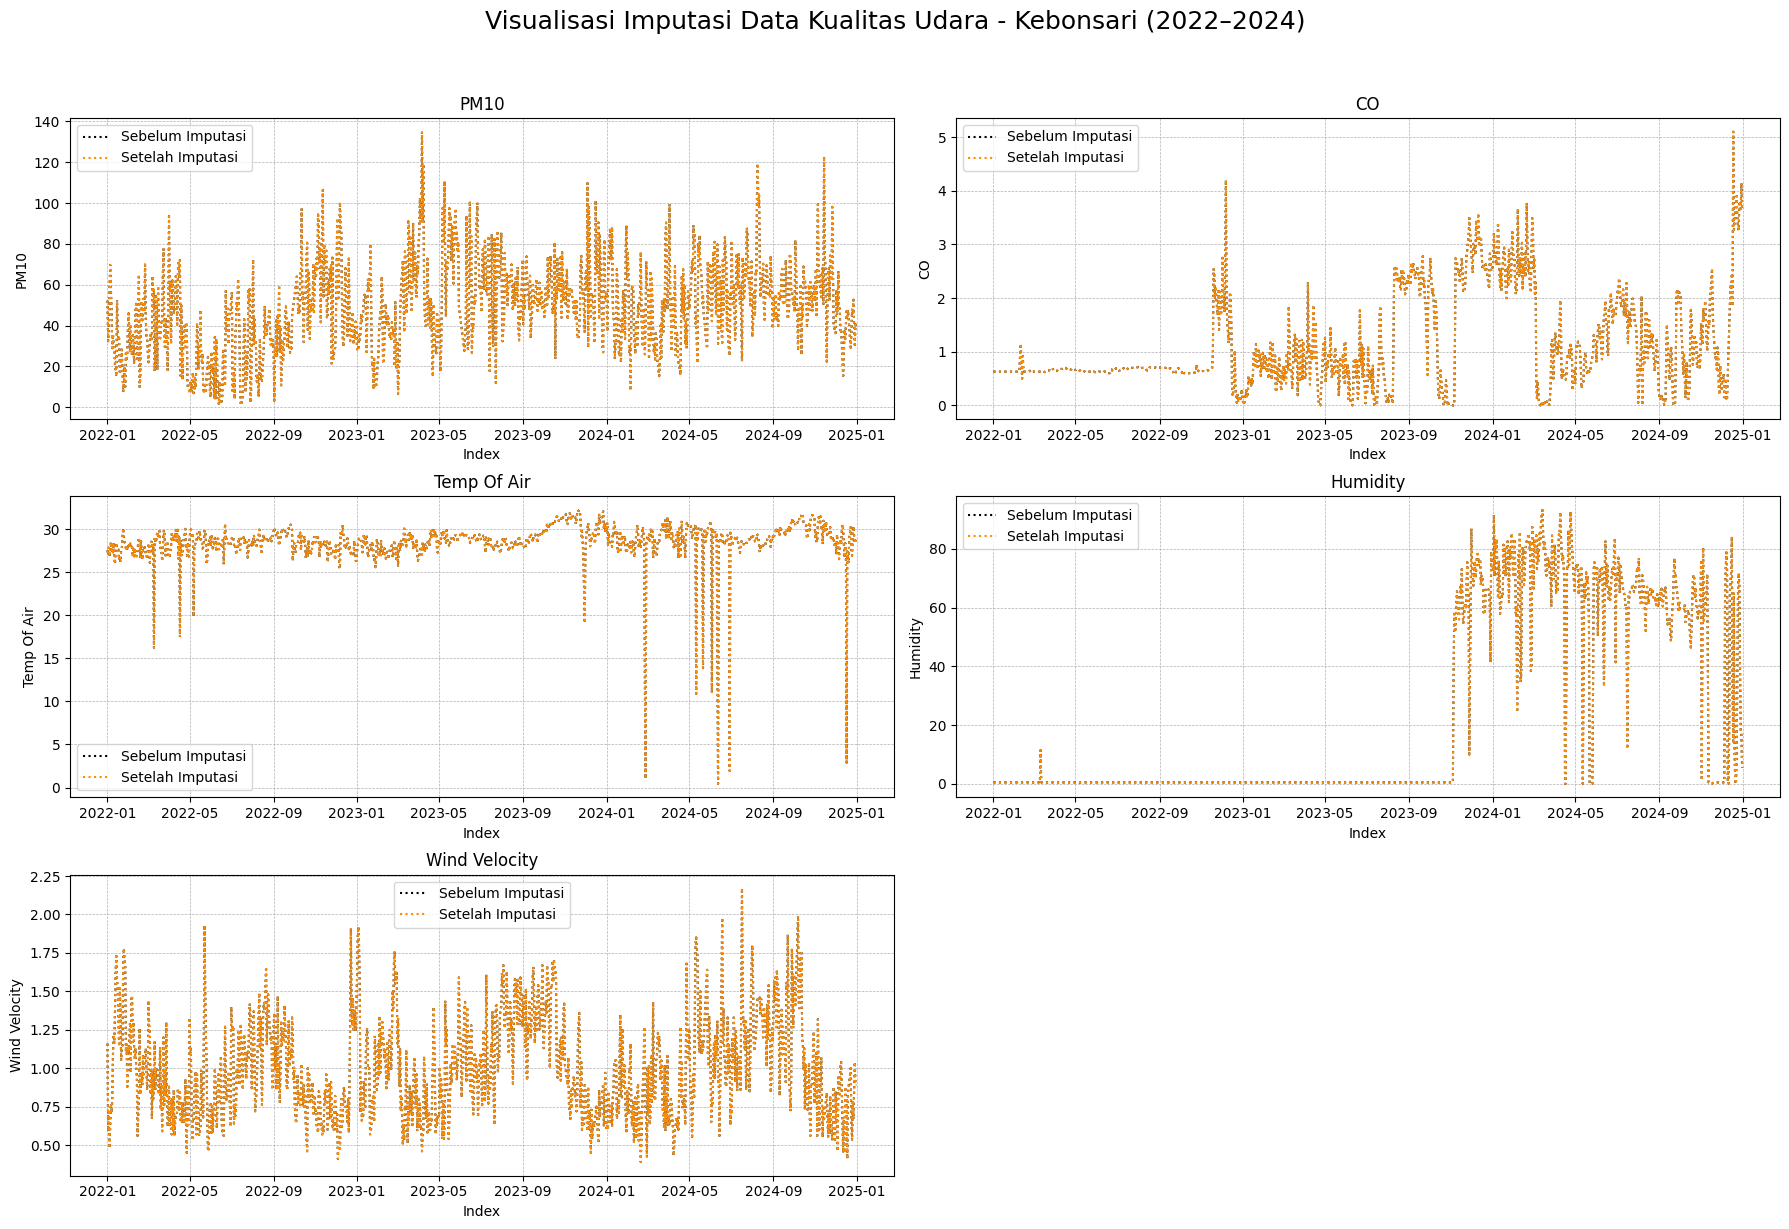

In [ ]:
plt.figure(figsize=(18, 12))

for i, kolom in enumerate(kolom_numerik):
    plt.subplot(3, 2, i + 1)

    # Plot sebelum imputasi (nilai asli, akan terlihat bolong)
    plt.plot(df.index, df
     [kolom], label='Sebelum Imputasi', linestyle='dotted', color='black')

    # Plot sesudah imputasi
    plt.plot(df.index, df[kolom], label='Setelah Imputasi', linestyle='dotted', color='darkorange')

    plt.title(f'{kolom}', fontsize=12)
    plt.ylabel(kolom)
    plt.xlabel('Index')  # TIDAK pakai tanggal
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()

plt.tight_layout()
plt.suptitle('Visualisasi Imputasi Data Kualitas Udara - Kebonsari (2022–2024)', fontsize=18, y=1.02)
plt.subplots_adjust(top=0.93)
plt.show()

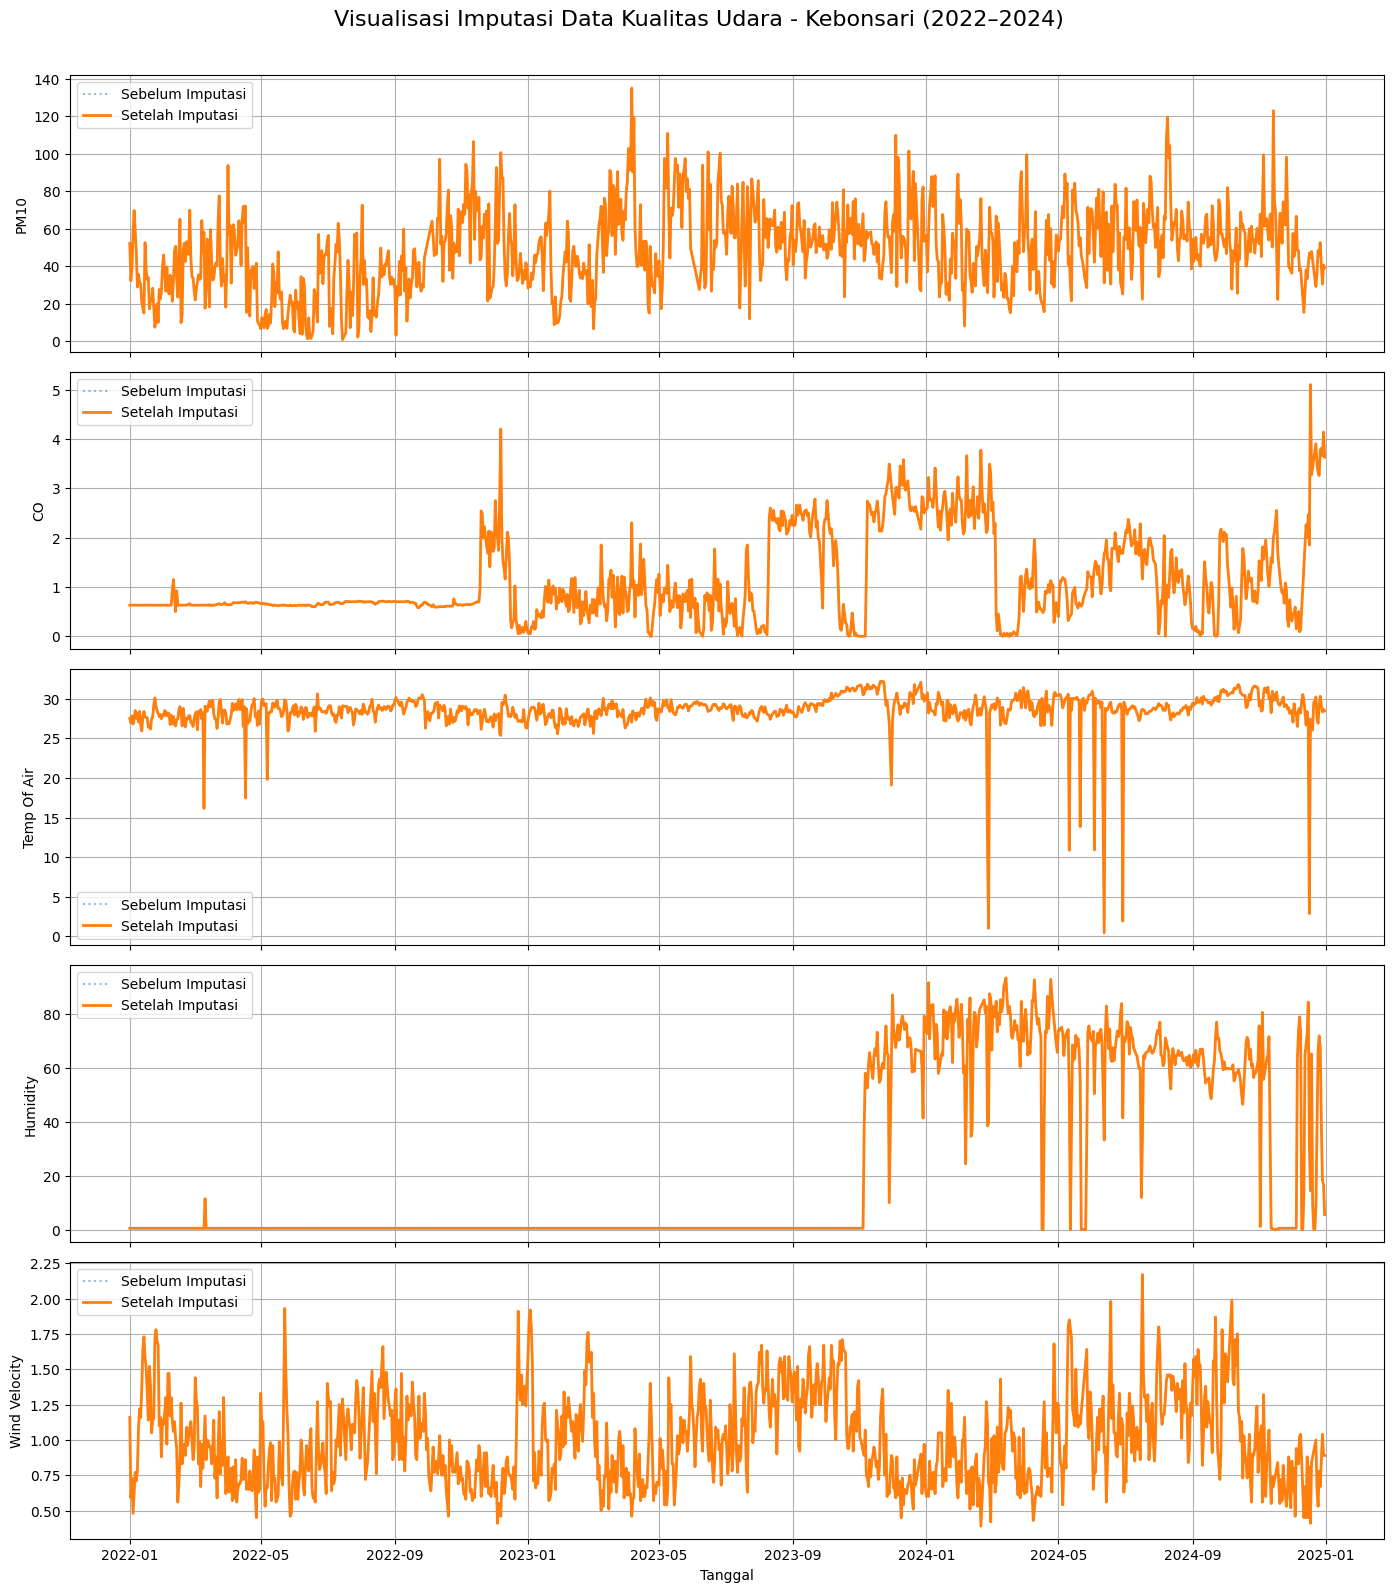

In [ ]:
params = ['PM10', 'CO', 'Temp Of Air', 'Humidity', 'Wind Velocity']

# Buat figure dan subplot
fig, axes = plt.subplots(nrows=len(params), ncols=1, figsize=(14, 16), sharex=True)

# Looping tiap parameter untuk plot
for i, param in enumerate(params):
    # Garis putus-putus: nilai asli (sebelum imputasi)
    axes[i].plot(df.index, df[param], label='Sebelum Imputasi', linestyle='dotted', alpha=0.5)
    # Garis tebal: nilai setelah interpolasi + imputasi
    axes[i].plot(df.index, df[param], label='Setelah Imputasi', linewidth=2)

    axes[i].set_ylabel(param)
    axes[i].legend()
    axes[i].grid(True)

# Judul utama plot
plt.suptitle('Visualisasi Imputasi Data Kualitas Udara - Kebonsari (2022–2024)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.xlabel("Tanggal")
plt.show()

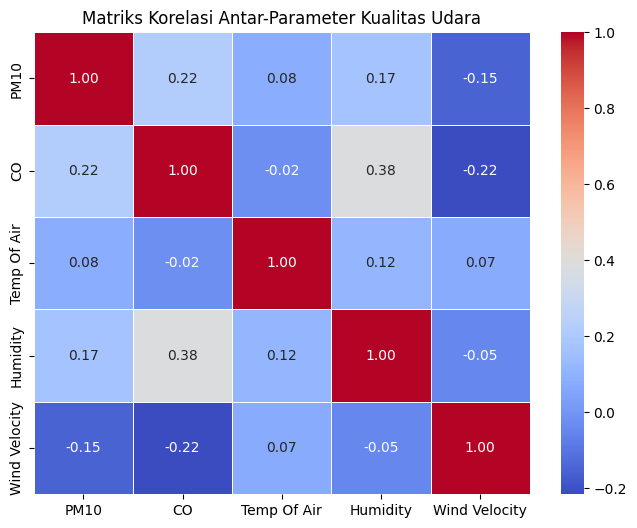

In [ ]:
numeric_cols = ['PM10', 'CO', 'Temp Of Air', 'Humidity', 'Wind Velocity']

# Drop baris yang mengandung NaN di kolom-kolom tersebut
df_corr = df[numeric_cols].dropna()

# Hitung matriks korelasi
correlation_matrix = df_corr.corr()

# Visualisasikan heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Antar-Parameter Kualitas Udara")
plt.show()

In [ ]:
#(df.set_index('Tanggal'))

# Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1096 entries, 2022-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PM10           1096 non-null   float64
 1   CO             1096 non-null   float64
 2   Temp Of Air    1096 non-null   float64
 3   Humidity       1096 non-null   float64
 4   Wind Velocity  1096 non-null   float64
dtypes: float64(5)
memory usage: 83.7 KB


In [ ]:
df.describe()

,PM10,CO,Temp Of Air,Humidity,Wind Velocity
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,48.718193,1.123718,28.609065,23.682222,1.002482
std,21.311503,0.871583,2.407596,32.579941,0.315842
min,0.870000,0.000000,0.440000,0.010000,0.390000
25%,33.660000,0.630000,28.037500,0.460000,0.750000
50%,48.380000,0.700000,28.740000,0.460000,0.955000
75%,62.015000,1.680000,29.550000,62.547500,1.220000
max,135.000000,5.100000,32.220000,93.280000,2.170000


In [ ]:
df.isnull().sum()

,0
PM10,0
CO,0
Temp Of Air,0
Humidity,0
Wind Velocity,0


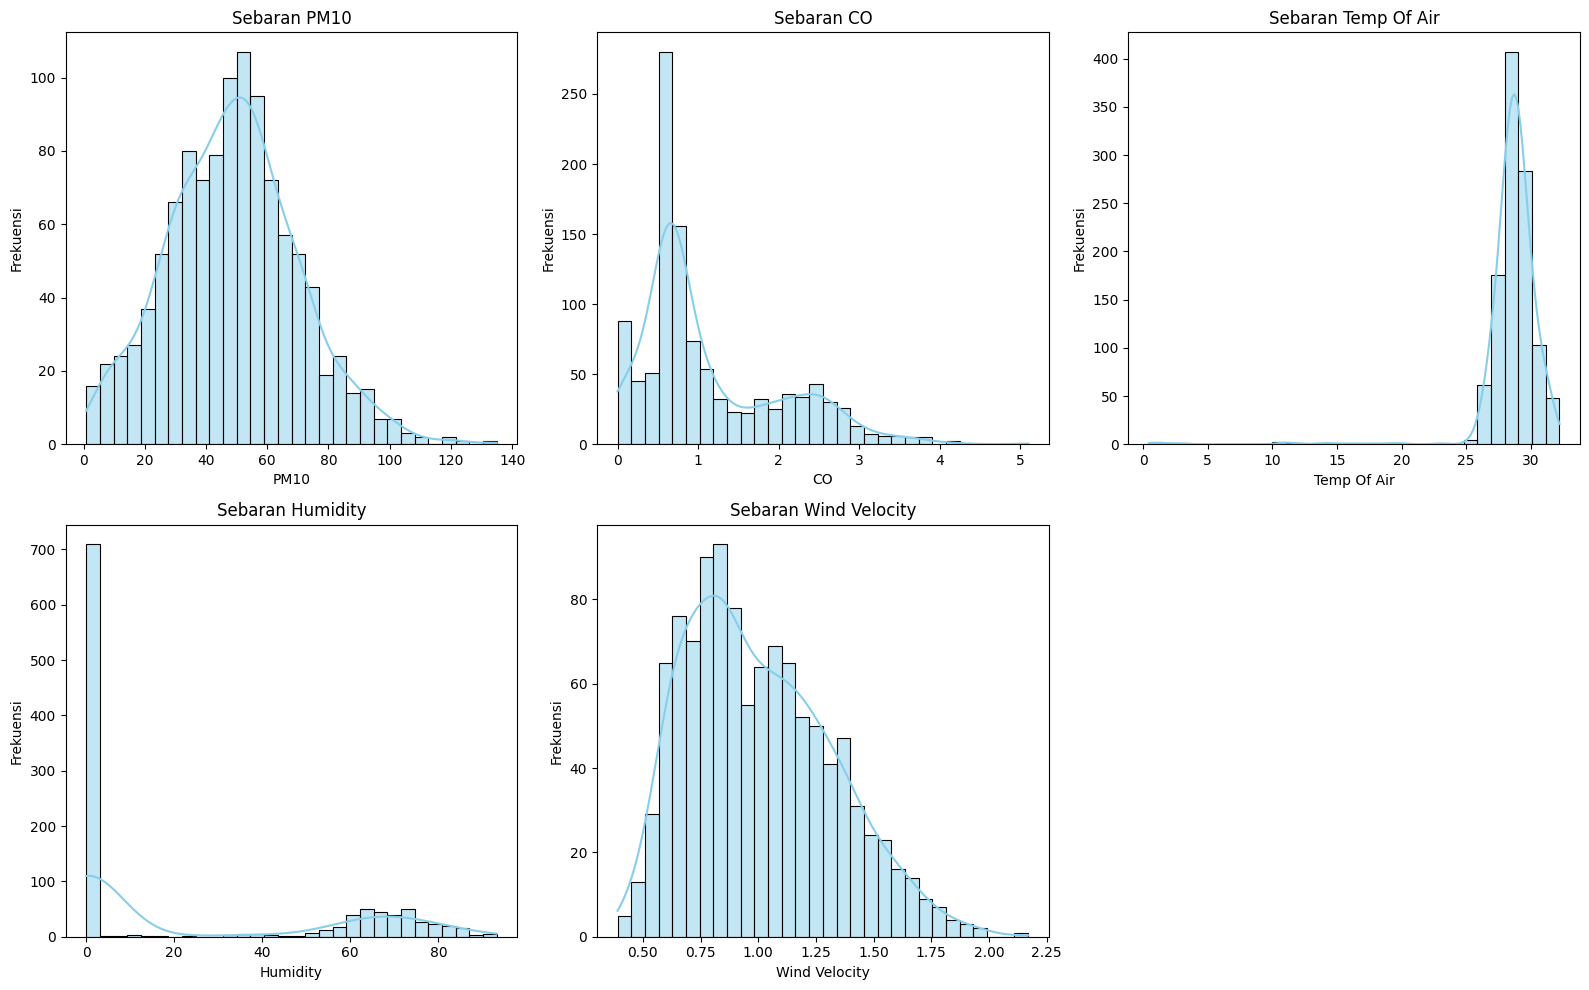

In [ ]:
# Cek apakah kolom-kolom berikut ada di df_after
numeric_cols = ['PM10', 'CO', 'Temp Of Air', 'Humidity', 'Wind Velocity']

# Plot sebaran (distribusi) tiap variabel
plt.figure(figsize=(16, 10))
for i, kolom in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[kolom], bins=30, kde=True, color='skyblue')
    plt.title(f'Sebaran {kolom}')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

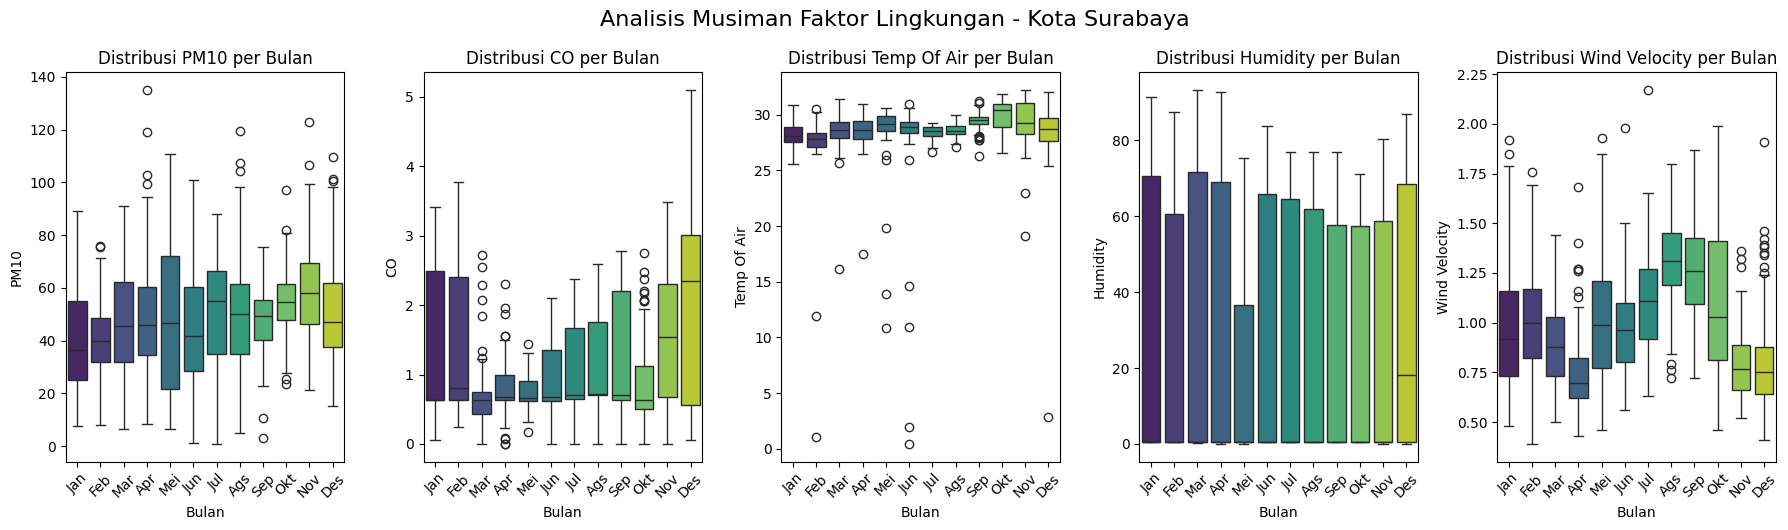

In [ ]:
# Ensure the index is datetime
df.index = pd.to_datetime(df.index)

# Extract month from the index
df['Bulan'] = df.index.month

bulan_dict = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'Mei', 6: 'Jun', 7: 'Jul', 8: 'Ags',
    9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}
df['Bulan'] = df['Bulan'].map(bulan_dict)
df['Bulan'] = pd.Categorical(df['Bulan'], categories=bulan_dict.values(), ordered=True)

# Tiga faktor lingkungan
faktor_lingkungan = ['PM10', 'CO','Temp Of Air', 'Humidity', 'Wind Velocity']

plt.figure(figsize=(18, 5))

for i, fitur in enumerate(faktor_lingkungan):
    plt.subplot(1, 5, i+1)
    sns.boxplot(x='Bulan', y=fitur, data=df, palette='viridis')
    plt.title(f'Distribusi {fitur} per Bulan')
    plt.xticks(rotation=45)
    plt.xlabel('Bulan')
    plt.ylabel(fitur)

plt.tight_layout()
plt.suptitle('Analisis Musiman Faktor Lingkungan - Kota Surabaya', fontsize=16, y=1.05)
plt.show()

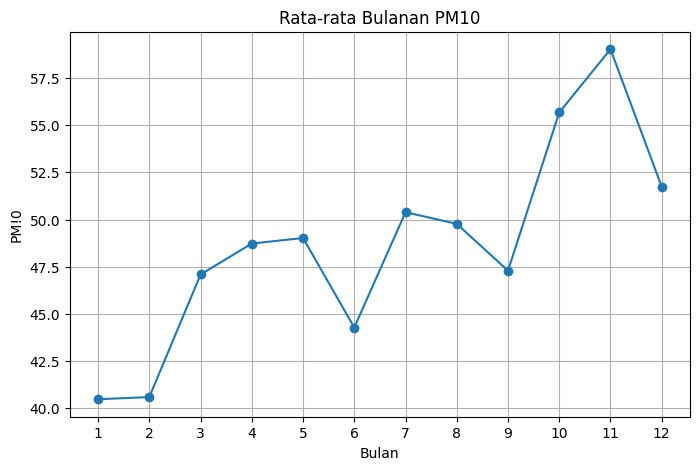

In [ ]:
#Pastikan index datetime
df.index = pd.to_datetime(df.index)

# Hitung rata-rata CO per bulan
rata2_bulanan_co = df['PM10'].groupby(df.index.month).mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(rata2_bulanan_co.index, rata2_bulanan_co.values, marker='o')
plt.title('Rata-rata Bulanan PM10')
plt.xlabel('Bulan')
plt.ylabel('PM!0')
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()

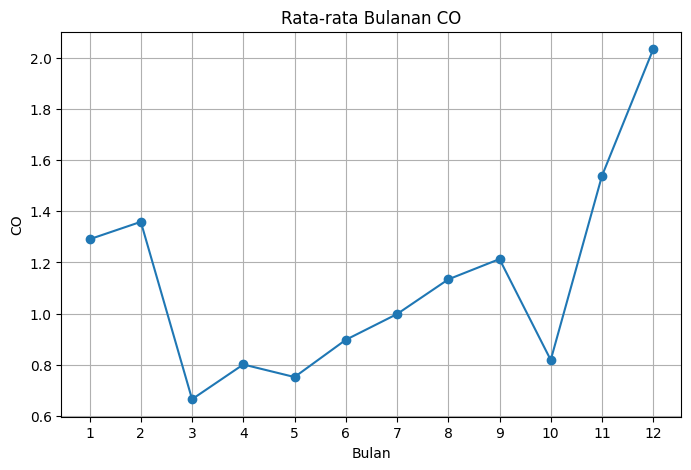

In [ ]:
#Pastikan index datetime
df.index = pd.to_datetime(df.index)

# Hitung rata-rata CO per bulan
rata2_bulanan_co = df['CO'].groupby(df.index.month).mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(rata2_bulanan_co.index, rata2_bulanan_co.values, marker='o')
plt.title('Rata-rata Bulanan CO')
plt.xlabel('Bulan')
plt.ylabel('CO')
plt.grid(True)
plt.xticks(range(1, 13))
plt.show()

#  Normalisasi

In [ ]:
fitur = ['PM10', 'CO', 'Temp Of Air', 'Humidity', 'Wind Velocity']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[fitur])
scaled_df = pd.DataFrame(scaled_data, columns=fitur, index=df.index)

In [ ]:
scaled_df

,PM10,CO,Temp Of Air,Humidity,Wind Velocity
Tanggal,,,,,
2022-01-01,0.382763,0.123529,0.852423,0.004825,0.432584
2022-01-02,0.234399,0.123529,0.835116,0.004825,0.112360
2022-01-03,0.283755,0.123529,0.862492,0.004825,0.191011
2022-01-04,0.424663,0.123529,0.829767,0.004825,0.050562
2022-01-05,0.513308,0.123529,0.851794,0.004825,0.134831
...,...,...,...,...,...
2024-12-27,0.386043,0.741176,0.940529,0.721883,0.157303
2024-12-28,0.292179,0.747059,0.905916,0.411386,0.258427
2024-12-29,0.220756,0.717647,0.877911,0.196205,0.365169


In [ ]:
# Urutkan berdasarkan waktu
scaled_df = scaled_df.sort_index()

# Definisikan target dan input
target_cols = ['PM10', 'CO']
input_cols = ['Temp Of Air', 'Humidity', 'Wind Velocity']
all_cols = target_cols + input_cols

data_array = scaled_df[all_cols].values

In [ ]:
def create_sequences_dual_target(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, :])      # semua kolom sebagai input
        y.append(data[i+time_step, :2])       # dua kolom pertama = PM10, CO sebagai target
    return np.array(X), np.array(y)

time_step = 24
X, y = create_sequences_dual_target(data_array, time_step)

## Split Data

In [ ]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Bangun Model LSTM

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
# Membangun model LSTM dengan Dropout
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.3))  # Tambahkan Dropout 30%
model.add(Dense(2))  # Output: PM10 dan CO
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,050 (70.51 KB)

 Trainable params: 18,050 (70.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0481 - val_loss: 0.0284
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0229 - val_loss: 0.0172
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0172 - val_loss: 0.0158
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0160 - val_loss: 0.0142
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0145 - val_loss: 0.0136
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0135 - val_loss: 0.0131
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0132 - val_loss: 0.0127
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - val_loss: 0.0126
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - val_loss: 0.0125
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0124 - val_loss: 0.0122
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0118 - val_loss: 0.0126
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0121 - val_l

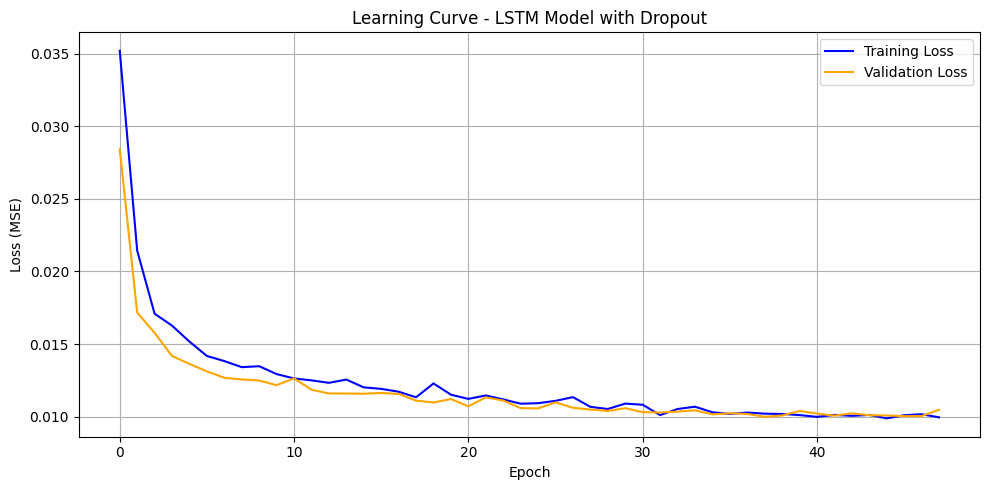

In [ ]:
# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Learning Curve - LSTM Model with Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Prediksi
y_pred = model.predict(X_test)

# Inverse Transform
X_input_last = X_test[:, -1, 2:]  # Ambil input fitur asli
y_pred_full = np.concatenate((y_pred, X_input_last), axis=1)
y_test_full = np.concatenate((y_test, X_input_last), axis=1)

# Pastikan urutan scaler.fit sama!
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, :2]
y_test_inv = scaler.inverse_transform(y_test_full)[:, :2]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


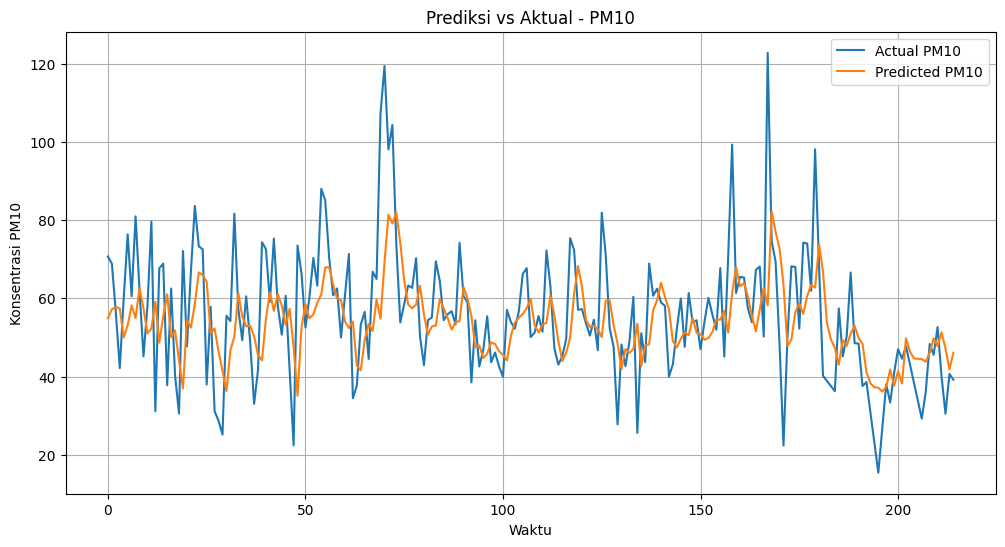

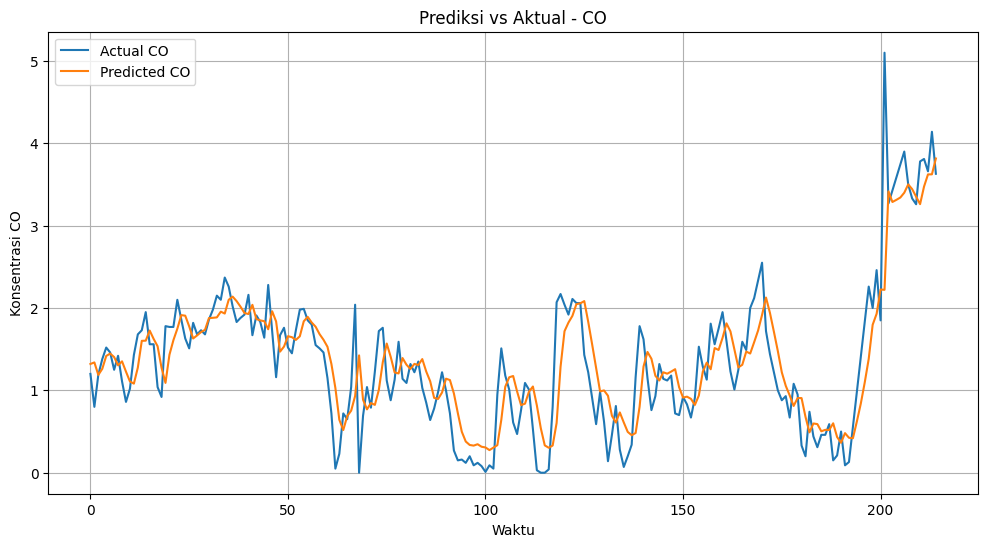

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:, 0], label='Actual PM10')
plt.plot(y_pred_inv[:, 0], label='Predicted PM10')
plt.title('Prediksi vs Aktual - PM10')
plt.xlabel('Waktu')
plt.ylabel('Konsentrasi PM10')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:, 1], label='Actual CO')
plt.plot(y_pred_inv[:, 1], label='Predicted CO')
plt.title('Prediksi vs Aktual - CO')
plt.xlabel('Waktu')
plt.ylabel('Konsentrasi CO')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluasi Per-Target
rmse_pm10 = np.sqrt(mean_squared_error(y_test_inv[:, 0], y_pred_inv[:, 0]))
mae_pm10 = mean_absolute_error(y_test_inv[:, 0], y_pred_inv[:, 0])
rmse_co = np.sqrt(mean_squared_error(y_test_inv[:, 1], y_pred_inv[:, 1]))
mae_co = mean_absolute_error(y_test_inv[:, 1], y_pred_inv[:, 1])

print(f'[PM10] RMSE: {rmse_pm10:.2f}, MAE: {mae_pm10:.2f}')
print(f'[CO]   RMSE: {rmse_co:.2f}, MAE: {mae_co:.2f}')

[PM10] RMSE: 14.94, MAE: 11.08
[CO]   RMSE: 0.44, MAE: 0.32


In [ ]:
# Evaluasi Keseluruhan
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)) * 100
    return smape

def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

r2 = r2_score(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = safe_mape(y_test_inv, y_pred_inv)
smape = symmetric_mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print("\n Evaluasi Keseluruhan Model Multivariat LSTM:")
print(f"R² Score   : {r2:.4f}")
print(f"MSE        : {mse:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"MAE        : {mae:.4f}")
print(f"MAPE       : {mape:.2f}%")
print(f"SMAPE      : {smape:.2f}%")



 Evaluasi Keseluruhan Model Multivariat LSTM:
R² Score   : 0.4773
MSE        : 111.7745
RMSE       : 10.5723
MAE        : 5.7017
MAPE       : 54.55%
SMAPE      : 28.74%


In [ ]:
print("\n Jumlah Data:")
print(f"Jumlah total data    : {len(y_train) + len(y_test)}")
print(f"Jumlah data training : {len(y_train)}")
print(f"Jumlah data testing  : {len(y_test)}")


 Jumlah Data:
Jumlah total data    : 1072
Jumlah data training : 857
Jumlah data testing  : 215


# Tuning Hyperparameter

In [ ]:
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import ParameterGrid

# Definisikan ruang pencarian hyperparameter
param_grid = {
    'units': [32, 64, 128],
    'dropout_rate': [0.2, 0.3, 0.5],
    'l2_rate': [1e-4, 1e-3],
    'batch_size': [16, 32],
    'epochs': [50]  #
}

grid = ParameterGrid(param_grid)

best_val_loss = float('inf')
best_model = None
best_params = None
best_history = None

for idx, params in enumerate(grid):
    print(f"Model ke-{idx+1} dengan params: {params}")

    # Membangun model LSTM
    model = Sequential()
    model.add(LSTM(
        units=params['units'],
        activation='tanh',
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        kernel_regularizer=l2(params['l2_rate'])
    ))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(y_train.shape[1]))  # Output layer sesuai jumlah target (2: PM10, CO)

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )

    val_loss = min(history.history['val_loss'])
    print(f"  Best val_loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params
        best_history = history


Model ke-1 dengan params: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 50, 'l2_rate': 0.0001, 'units': 32}
  Best val_loss: 0.0105
Model ke-2 dengan params: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 50, 'l2_rate': 0.0001, 'units': 64}
  Best val_loss: 0.0104
Model ke-3 dengan params: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 50, 'l2_rate': 0.0001, 'units': 128}
  Best val_loss: 0.0104
Model ke-4 dengan params: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 50, 'l2_rate': 0.001, 'units': 32}
  Best val_loss: 0.0113
Model ke-5 dengan params: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 50, 'l2_rate': 0.001, 'units': 64}
  Best val_loss: 0.0110
Model ke-6 dengan params: {'batch_size': 16, 'dropout_rate': 0.2, 'epochs': 50, 'l2_rate': 0.001, 'units': 128}
  Best val_loss: 0.0112
Model ke-7 dengan params: {'batch_size': 16, 'dropout_rate': 0.3, 'epochs': 50, 'l2_rate': 0.0001, 'units': 32}
  Best val_loss: 0.0104
Model ke-8 dengan params: {'batch_size': 16, 'dro

In [ ]:
# Hasil Terbaik
print("\n Best Hyperparameters:")
print(best_params)


 Best Hyperparameters:
{'batch_size': 16, 'dropout_rate': 0.3, 'epochs': 50, 'l2_rate': 0.0001, 'units': 128}


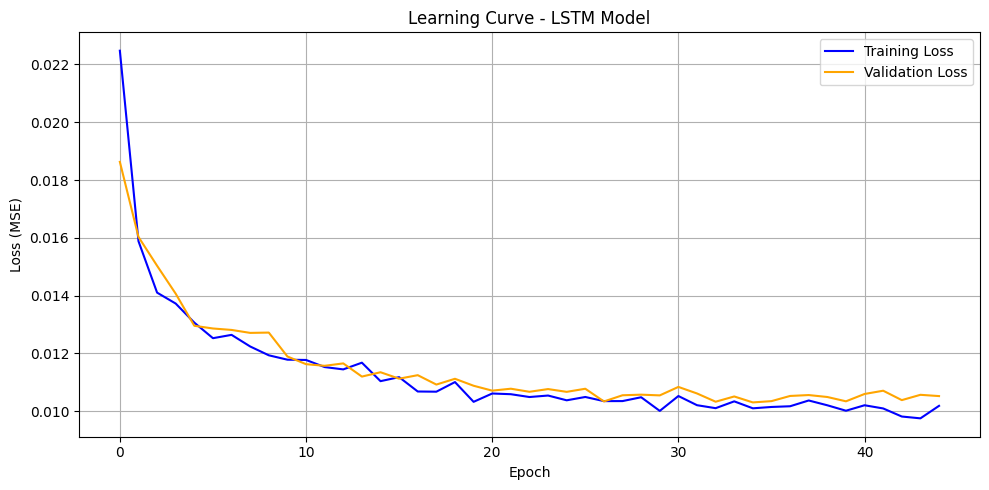

In [ ]:
# Plot Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(best_history.history['loss'], label='Training Loss', color='blue')
plt.plot(best_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Learning Curve - LSTM Model')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Prediksi
y_pred = best_model.predict(X_test)

# Inverse Transform
X_input_last = X_test[:, -1, 2:]
y_pred_full = np.concatenate((y_pred, X_input_last), axis=1)
y_test_full = np.concatenate((y_test, X_input_last), axis=1)

y_pred_inv = scaler.inverse_transform(y_pred_full)[:, :2]
y_test_inv = scaler.inverse_transform(y_test_full)[:, :2]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


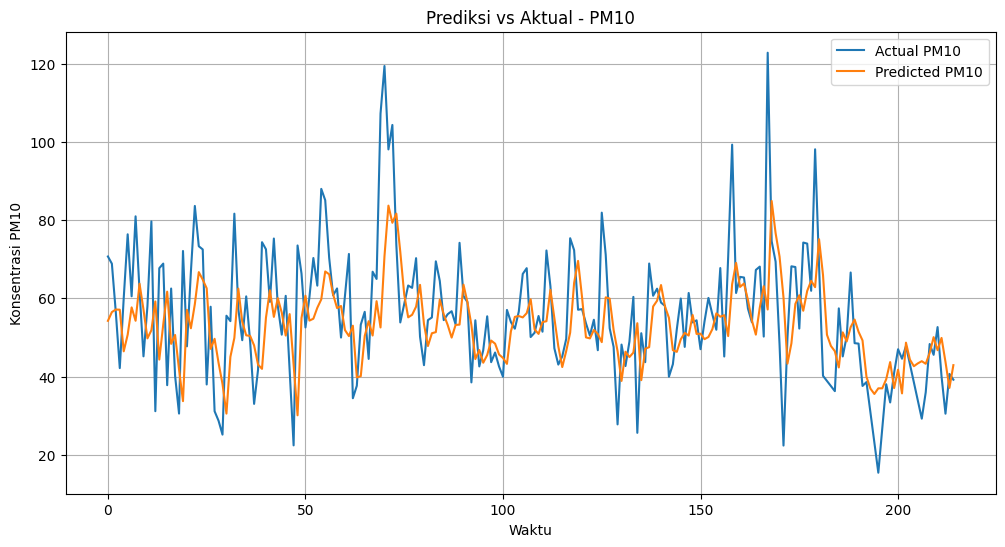

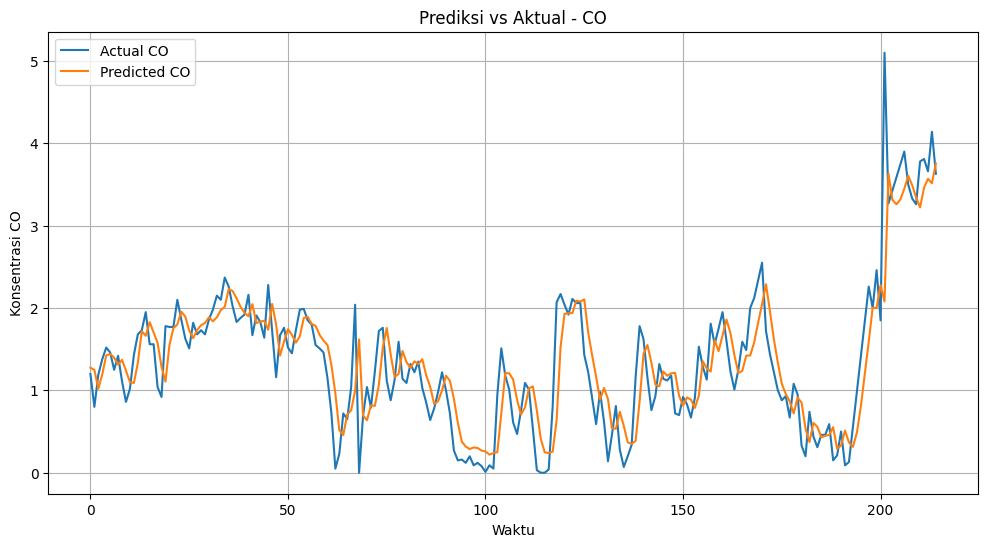

In [ ]:
# Visualisasi
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:, 0], label='Actual PM10')
plt.plot(y_pred_inv[:, 0], label='Predicted PM10')
plt.title('Prediksi vs Aktual - PM10')
plt.xlabel('Waktu')
plt.ylabel('Konsentrasi PM10')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:, 1], label='Actual CO')
plt.plot(y_pred_inv[:, 1], label='Predicted CO')
plt.title('Prediksi vs Aktual - CO')
plt.xlabel('Waktu')
plt.ylabel('Konsentrasi CO')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluasi
rmse_pm10 = np.sqrt(mean_squared_error(y_test_inv[:, 0], y_pred_inv[:, 0]))
mae_pm10 = mean_absolute_error(y_test_inv[:, 0], y_pred_inv[:, 0])
rmse_co = np.sqrt(mean_squared_error(y_test_inv[:, 1], y_pred_inv[:, 1]))
mae_co = mean_absolute_error(y_test_inv[:, 1], y_pred_inv[:, 1])

print(f'[PM10] RMSE: {rmse_pm10:.2f}, MAE: {mae_pm10:.2f}')
print(f'[CO]   RMSE: {rmse_co:.2f}, MAE: {mae_co:.2f}')


[PM10] RMSE: 15.07, MAE: 11.17
[CO]   RMSE: 0.44, MAE: 0.31


In [ ]:
# Tambahan MAPE dan SMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)) * 100
    return smape

def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

r2 = r2_score(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape = safe_mape(y_test_inv, y_pred_inv)
smape = symmetric_mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print("\n Evaluasi Keseluruhan Model Multivariat Setelah Tuning LSTM:")
print(f"R² Score   : {r2:.4f}")
print(f"MSE        : {mse:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"MAE        : {mae:.4f}")
print(f"MAPE       : {mape:.2f}%")
print(f"SMAPE      : {smape:.2f}%")


 Evaluasi Keseluruhan Model Multivariat Setelah Tuning LSTM:
R² Score   : 0.4754
MSE        : 113.6211
RMSE       : 10.6593
MAE        : 5.7392
MAPE       : 49.45%
SMAPE      : 28.17%
